# The Training Loop — Hands-on Tutorial

In this notebook you will build intuition for:
1. What the training loop actually does — step by step, nothing hidden
2. How learning rate controls convergence speed and stability
3. How batch size affects the loss curve and compute cost
4. How model capacity drives the gap between training and validation loss

## Where this fits

| # | Topic | Slide deck | Notebook |
|---|---|---|---|
| 1 | Single neuron | `01_single_neuron.pdf` | `01_single_neuron.ipynb` |
| **→ 2** | **Multilayer networks** | **`02_multilayer_networks.pdf`** | **`02_training_loop.ipynb`** |
| 3 | Backpropagation | `03_backprop_training.pdf` | `03_backpropagation.ipynb` |
| 4 | Optimizers | `07_optimizers.pdf` *(new)* | `04_optimizers.ipynb` |
| 5 | CNNs | `04_cnns.pdf` | `05_cnns.ipynb` |
| 6 | Modern architectures | `05a_attention.pdf` + `05b_practical.pdf` | *(bonus: `bonus_generative_models.ipynb`)* |
| 7 | Bayesian inference | `06_bayesian_inference.pdf` | `06_bayesian_inference.ipynb` |

**Coming from:** Notebook 01 introduced a single neuron with a fixed boundary; here you actually train one with a real loss and optimizer.

**Leading to:** Notebook 03 cracks open `loss.backward()` and shows where the gradients came from.

**If you skipped ahead:** Be comfortable with the neuron equation: weight times input plus bias, passed through an activation.


In [2]:
# Run on Colab only — skip on JupyterHub (packages are pre-installed)
import sys
if 'google.colab' in sys.modules:
    %pip install -q ipywidgets torch

import numpy as np
import torch
import torch.nn as nn
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, ToggleButtons

%matplotlib inline

# ── Astronomy dataset: photometric redshift estimation ─────────────────────
# Synthetic galaxy photometry inspired by SDSS colour–redshift relations.
# Feature 1: g−r colour  (redder galaxies tend to be at lower redshift)
# Feature 2: r−i colour
# Target:    spectroscopic redshift z ∈ [0.02, 0.40]
#
# The true relationship is approximately linear, with realistic scatter.

torch.manual_seed(7)
np.random.seed(7)

N = 200
z_true = np.random.uniform(0.02, 0.40, N)

gr = 0.80 * z_true + 0.15 + np.random.normal(0, 0.04, N)
ri = 0.40 * z_true + 0.05 + np.random.normal(0, 0.03, N)

X_np = np.column_stack([gr, ri]).astype(np.float32)
y_np = z_true.astype(np.float32).reshape(-1, 1)

X = torch.from_numpy(X_np)
y = torch.from_numpy(y_np)

# 80 / 20 train–validation split
n_train = int(0.8 * N)
X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]

print(f"Train: {X_train.shape}   Val: {X_val.shape}")
print(f"Redshift range: {y_np.min():.2f} – {y_np.max():.2f}")

Train: torch.Size([160, 2])   Val: torch.Size([40, 2])
Redshift range: 0.02 – 0.40


---

## Warm-up — the XOR network by hand

Before we *train* anything, let us confirm we understand the *forward pass* on a
network whose weights we already know. This is the 2 → 2 → 1 XOR network from the
slides, with the exact hand-set weights. Run it and read every number; then verify
it matches `nn.Sequential`.

In [ ]:
# ── The XOR network by hand: real weights, every number printed ─────────────
import numpy as np

# A complete 2 -> 2 (ReLU) -> 1 network that solves XOR (from the slides).
W1 = np.array([[1., 1.],
               [1., 1.]])
b1 = np.array([0., -1.])
W2 = np.array([1., -2.])
b2 = 0.0

def relu(z):
    return np.maximum(0.0, z)

def forward(x):
    z1 = W1 @ x + b1          # linear layer 1
    a1 = relu(z1)             # ReLU activation
    z2 = W2 @ a1 + b2         # linear layer 2 (scalar)
    y  = int(z2 > 0.5)        # threshold to a class
    return z1, a1, z2, y

print(f"{'x':>7} | {'z1':>10} | {'a1=ReLU':>10} | {'z2':>5} | y | XOR")
print('-' * 52)
for x in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    z1, a1, z2, y = forward(np.array(x, float))
    xor = x[0] ^ x[1]
    ok = 'OK' if y == xor else 'WRONG'
    print(f"{str(x):>7} | {str(z1):>10} | {str(a1):>10} | {z2:>5.1f} | {y} |  {xor}  {ok}")

# ── Verify against PyTorch (same weights, nn.Linear stores W as (out, in)) ───
import torch, torch.nn as nn
net = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 1))
with torch.no_grad():
    net[0].weight.copy_(torch.tensor(W1)); net[0].bias.copy_(torch.tensor(b1))
    net[2].weight.copy_(torch.tensor(W2).unsqueeze(0)); net[2].bias.copy_(torch.tensor([b2]))
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
print("\nPyTorch z2 :", net(X).squeeze().round(decimals=3).tolist())
print("by-hand z2 :", [forward(np.array(x, float))[2] for x in [(0,0),(0,1),(1,0),(1,1)]])
print("\nSame numbers -> the hand calculation and nn.Sequential agree.")

### Play with it — the interactive forward pass

Pick an input, then drag the two layer-1 biases. Watch `z1`, `a1`, `z2` update, and
watch the **whole truth table break** the moment you move the weights off the
hand-crafted solution — a concrete feel for how specific the solution is.

In [ ]:
# ── Widget: step the XOR forward pass, and bend the weights yourself ────────
# Pick an input with the dropdowns; nudge the layer-1 biases with the sliders.
# Watch z1, a1, z2 update live — and watch the truth table break when you move
# the weights away from the hand-crafted solution.
from ipywidgets import interact, Dropdown, FloatSlider

def xor_explorer(x1=0, x2=1, b1_0=0.0, b1_1=-1.0):
    W1 = np.array([[1., 1.], [1., 1.]])
    b1 = np.array([b1_0, b1_1])
    W2 = np.array([1., -2.]); b2 = 0.0
    x = np.array([float(x1), float(x2)])

    z1 = W1 @ x + b1
    a1 = np.maximum(0.0, z1)
    z2 = W2 @ a1 + b2
    y  = int(z2 > 0.5)

    print(f"input  x        = [{x1}, {x2}]")
    print(f"z1 = W1·x + b1   = [{z1[0]:+.2f}, {z1[1]:+.2f}]   "
          f"(bias = [{b1_0:+.2f}, {b1_1:+.2f}])")
    print(f"a1 = ReLU(z1)    = [{a1[0]:+.2f}, {a1[1]:+.2f}]")
    print(f"z2 = W2·a1 + b2  = {z2:+.2f}")
    print(f"prediction ŷ     = {y}     (XOR = {x1 ^ x2})   "
          f"{'✓ correct' if y == (x1 ^ x2) else '✗ wrong'}")

    # Does the CURRENT setting still solve all four cases?
    ok = True
    for a in (0, 1):
        for b in (0, 1):
            zz = W2 @ np.maximum(0.0, W1 @ np.array([a, b], float) + b1) + b2
            if int(zz > 0.5) != (a ^ b):
                ok = False
    print("\nWhole truth table:", "still solved ✓" if ok
          else "BROKEN ✗  — you moved the weights off the solution")

interact(xor_explorer,
         x1=Dropdown(options=[0, 1], value=0, description='x1'),
         x2=Dropdown(options=[0, 1], value=1, description='x2'),
         b1_0=FloatSlider(value=0.0,  min=-2, max=2, step=0.25, description='bias h1'),
         b1_1=FloatSlider(value=-1.0, min=-2, max=2, step=0.25, description='bias h2'));

### Think about it

- With the sliders at their defaults the table is solved. Set **`bias h2` to −0.5**.
  Which input(s) now misclassify, and why? (Hint: when does hidden unit 2 wrongly stay on?)
- Hidden unit 2 has bias −1 so it only fires when `x1 + x2 = 2`. What is it *detecting*?
- The output weight on unit 2 is −2. Make it −1 (edit the code). Which case breaks?
- We *chose* these weights. In the rest of the notebook, gradient descent will
  **find** weights like these on its own — that is the whole game.

---

## The mathematics of the training loop

### The loss function — MSE

$$L(\mathbf{w}, b) = \frac{1}{N} \sum_{i=1}^{N} \left(\hat{y}_i - y_i\right)^2$$

| Symbol | Meaning |
|--------|---------|
| $N$ | Number of training examples |
| $\hat{y}_i = \mathbf{w}\cdot\mathbf{x}_i + b$ | Model prediction for example $i$ |
| $y_i$ | True label (target redshift here) |
| $L$ | Scalar loss — the number we want to minimise |

MSE penalises large errors quadratically — a prediction off by 2 costs four times as much as one off by 1.

### The gradient descent update

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \, \nabla_{\mathbf{w}} L, \qquad b \leftarrow b - \eta \, \frac{\partial L}{\partial b}$$

For a linear model with MSE loss the gradients are analytic:

$$\nabla_{\mathbf{w}} L = \frac{2}{N} X^\top (\hat{\mathbf{y}} - \mathbf{y}), \qquad \frac{\partial L}{\partial b} = \frac{2}{N} \sum_i (\hat{y}_i - y_i)$$

| Symbol | Meaning |
|--------|---------|
| $\eta$ | Learning rate — controls the step size |
| $X \in \mathbb{R}^{N \times n}$ | Design matrix — all training inputs stacked as rows |
| $\hat{\mathbf{y}} - \mathbf{y}$ | Residual vector — how wrong we are at each example |
| $X^\top(\hat{\mathbf{y}} - \mathbf{y})$ | Each feature's total contribution to the error |

The gradient points **uphill** — we step in the opposite direction to descend.

In [ ]:
# ── Implement MSE and its gradient; visualise the 1D loss curve ───────────────

# Use w2 (galaxy colour r−i) as the free parameter; fix w1 and b at reasonable values
w1_fixed = 1.5
b_fixed  = -0.1

X_np = X_train.numpy()
y_np = y_train.numpy()

def mse(w2_val):
    w = np.array([[w1_fixed], [w2_val]])
    y_hat = X_np @ w + b_fixed
    return float(np.mean((y_hat - y_np) ** 2))

def mse_gradient_w2(w2_val):
    """Analytic gradient dL/dw2 for a linear model."""
    w = np.array([[w1_fixed], [w2_val]])
    y_hat = X_np @ w + b_fixed
    residuals = y_hat - y_np                    # (N,1)
    grad = (2 / len(X_np)) * (X_np[:, 1:2].T @ residuals)   # dL/dw2
    return float(grad)

w2_range = np.linspace(-1.0, 4.0, 200)
losses   = [mse(w2) for w2 in w2_range]

# Mark two points: a bad start and after one gradient step
w2_start = 3.5
eta      = 0.5
w2_step  = w2_start - eta * mse_gradient_w2(w2_start)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(w2_range, losses, lw=2.5, color='steelblue', label='$L(w_2)$ — MSE loss')

# Gradient arrow at w2_start
g = mse_gradient_w2(w2_start)
ax.annotate('', xy=(w2_start - 0.45, mse(w2_start) - 0.45 * g * 0.4),
            xytext=(w2_start, mse(w2_start)),
            arrowprops=dict(arrowstyle='->', color='tomato', lw=2))
ax.plot(w2_start, mse(w2_start), 'o', color='tomato', ms=9, zorder=5,
        label=f'Start  $w_2={w2_start}$,  $L={mse(w2_start):.4f}$')

ax.plot(w2_step, mse(w2_step), 's', color='green', ms=9, zorder=5,
        label=f'After one step ($\eta={eta}$)  $w_2={w2_step:.3f}$,  $L={mse(w2_step):.4f}$')

ax.annotate(f'gradient = {g:.3f}\n(arrow points uphill)', xy=(w2_start + 0.05, mse(w2_start)),
            fontsize=9, color='tomato')

ax.set_xlabel('$w_2$  (weight on $r-i$ colour)')
ax.set_ylabel('MSE loss $L$')
ax.set_title('Loss as a function of $w_2$\n(w₁ and b fixed)  —  one gradient descent step shown')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gradient dL/dw₂ at w₂={w2_start}: {g:.4f}  (positive → loss rises as w₂ increases)')
print(f'Step: w₂ = {w2_start} − {eta} × {g:.4f} = {w2_step:.4f}')
print(f'Loss reduced from {mse(w2_start):.4f} to {mse(w2_step):.4f}')


### Think about it

- The loss curve is bowl-shaped (convex). Is this always the case for MSE with a   linear model? What property of the model guarantees a single minimum?
- The gradient arrow points uphill along the loss curve. If you took a step   *in the direction of* the gradient instead of against it, what would happen   to the loss?
- The gradient $\nabla_{\mathbf{w}} L = \frac{2}{N} X^\top (\hat{\mathbf{y}} - \mathbf{y})$   is a weighted sum of the input features. What does it mean when   $\hat{y}_i = y_i$ for all $i$? What is the gradient then?
- If you scale all inputs by a factor of 10, the gradient scales by 10 too.   What does this tell you about how learning rate should change with input scale?

---

## Part 1: The training loop anatomy

A training loop has exactly four steps, repeated for every epoch:

1. **Forward pass** — run the data through the model, get predictions
2. **Loss** — measure how wrong the predictions are
3. **Backward pass** — compute gradients of the loss with respect to every parameter
4. **Update** — nudge each parameter in the direction that reduces the loss

We will execute each step as a separate cell so you can see the intermediate state.

**Task:** predict photometric redshift from two galaxy colours.
The model is a single linear neuron: $\hat{z} = w_1 \cdot (g-r) + w_2 \cdot (r-i) + b$.

*In ML-generic terms: two-feature regression with a real-valued target, mild noise.*

In [3]:
# ── Step 1: Forward pass ───────────────────────────────────────────────────
# Initialise random weights. The model knows nothing yet.

torch.manual_seed(0)
w = torch.randn(2, 1, requires_grad=True)   # shape (2, 1)
b = torch.zeros(1,    requires_grad=True)   # shape (1,)

z_pred = X_train @ w + b                   # shape (n_train, 1)

print(f"w = {w.squeeze().detach().numpy()}")
print(f"b = {b.item():.4f}")
print()
print(f"First 5 predictions : {z_pred[:5].squeeze().detach().numpy()}")
print(f"First 5 true values : {y_train[:5].squeeze().numpy()}")

w = [ 1.5409961 -0.2934289]
b = 0.0000

First 5 predictions : [0.19544128 0.6154819  0.50072825 0.6127935  0.5905192 ]
First 5 true values : [0.04899715 0.31636915 0.18659551 0.29491678 0.391636  ]


In [4]:
# ── Step 2: Loss ───────────────────────────────────────────────────────────
# Mean Squared Error: average squared difference between prediction and truth.
#
#   L = (1/N) Σ (ẑᵢ − zᵢ)²
#
# MSE has units of redshift². RMSE gives an interpretable number.

loss = torch.mean((z_pred - y_train) ** 2)

print(f"MSE loss = {loss.item():.6f}")
print(f"RMSE     = {loss.item()**0.5:.4f}  (in redshift units)")
print()
print("Typical spectroscopic redshift accuracy: σ_z ~ 0.001")
print("Our model is nowhere near that yet.")

MSE loss = 0.061438
RMSE     = 0.2479  (in redshift units)

Typical spectroscopic redshift accuracy: σ_z ~ 0.001
Our model is nowhere near that yet.


In [5]:
# ── Step 3: Backward pass ──────────────────────────────────────────────────
# Compute dL/dw and dL/db via the chain rule.
# PyTorch tracks every operation on tensors with requires_grad=True
# and applies backpropagation automatically when we call .backward().

loss.backward()

print(f"dL/dw = {w.grad.squeeze().numpy()}")
print(f"dL/db = {b.grad.item():.6f}")
print()
print("The gradient points in the direction that INCREASES the loss.")
print("We will step in the OPPOSITE direction.")

dL/dw = [0.15909159 0.06302943]
dL/db = 0.481085

The gradient points in the direction that INCREASES the loss.
We will step in the OPPOSITE direction.


In [6]:
# ── Step 4: Parameter update ───────────────────────────────────────────────
# Gradient descent: θ ← θ − η · ∇L
#
# torch.no_grad() disables gradient tracking during the update —
# we do not want PyTorch to build a computation graph for the update itself.

lr = 0.1

with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad

# Zero the gradients — they ACCUMULATE if not cleared
w.grad.zero_()
b.grad.zero_()

# Measure the improvement
z_pred_new = X_train @ w + b
loss_new = torch.mean((z_pred_new - y_train) ** 2)

print(f"Loss before: {loss.item():.6f}")
print(f"Loss after : {loss_new.item():.6f}")
print(f"Improvement: {loss.item() - loss_new.item():.6f}")

Loss before: 0.061438
Loss after : 0.038280
Improvement: 0.023159


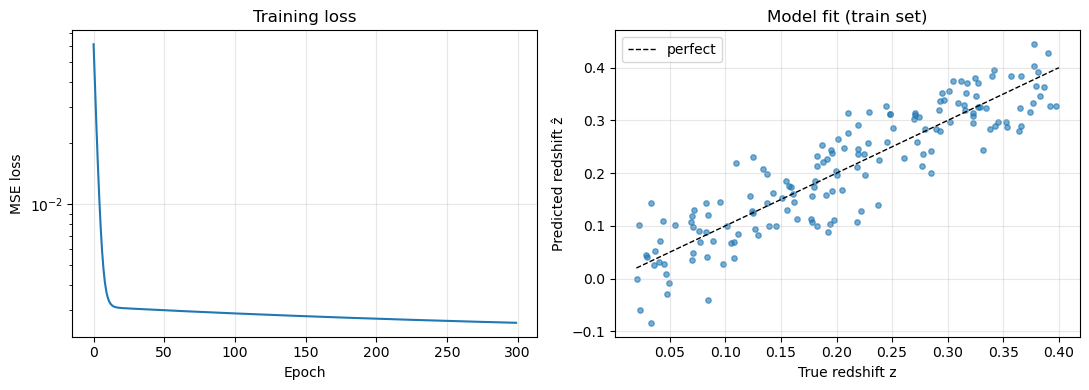

Final w = [ 1.3536428  -0.31238678]
Final b = -0.1793   Final loss = 0.002606


In [8]:
# ── Full loop: 300 epochs ──────────────────────────────────────────────────
# The four steps above, automated. Watch the loss curve converge.

torch.manual_seed(0)
w = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1,    requires_grad=True)
lr = 0.1

losses = []
for epoch in range(300):
    z_pred = X_train @ w + b
    loss   = torch.mean((z_pred - y_train) ** 2)

    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()

    losses.append(loss.item())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(losses, color='tab:blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE loss')
axes[0].set_title('Training loss')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

z_hat = (X_train @ w + b).detach().numpy()
axes[1].scatter(y_train.numpy(), z_hat, s=15, alpha=0.6, color='tab:blue')
axes[1].plot([0.02, 0.40], [0.02, 0.40], 'k--', lw=1, label='perfect')
axes[1].set_xlabel('True redshift z')
axes[1].set_ylabel('Predicted redshift ẑ')
axes[1].set_title('Model fit (train set)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final w = {w.squeeze().detach().numpy()}")
print(f"Final b = {b.item():.4f}   Final loss = {losses[-1]:.6f}")

---

### Weight trajectory on the loss surface

The loss curve shows *when* the model improves. The plot below shows *where* the weights move — their path traced on the MSE loss surface in $(w_1, w_2)$ space. The bias $b$ is projected out (marginalised) so we can see the 2D trajectory.

This connects directly to the Part 2 slider: different learning rates produce qualitatively different trajectories on the same surface.

In [ ]:
# ── Weight trajectory during training ─────────────────────────────────────────

def loss_surface_2d(X, y, w1_vals, w2_vals):
    """MSE surface over (w1, w2) grid, b=0 for visualisation."""
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    L = np.zeros_like(W1)
    X_np, y_np = X.numpy(), y.numpy()
    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            pred = X_np @ np.array([W1[i,j], W2[i,j]]) 
            L[i, j] = np.mean((pred - y_np.squeeze()) ** 2)
    return W1, W2, L

w1_grid = np.linspace(-2.0, 3.0, 60)
w2_grid = np.linspace(-1.5, 3.0, 60)
W1g, W2g, Lg = loss_surface_2d(X_train, y_train, w1_grid, w2_grid)

# Run three training scenarios, recording weight trajectory
def run_and_track(lr, n_epochs=300, seed=0):
    torch.manual_seed(seed)
    w = torch.randn(2, 1, requires_grad=True)
    b = torch.zeros(1,    requires_grad=True)
    w_traj = [w.detach().numpy().flatten().copy()]
    for _ in range(n_epochs):
        pred = X_train @ w + b
        loss = torch.mean((pred - y_train) ** 2)
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
        w.grad.zero_(); b.grad.zero_()
        w_traj.append(w.detach().numpy().flatten().copy())
    return np.array(w_traj)

traj_slow   = run_and_track(lr=0.001)
traj_good   = run_and_track(lr=0.10)
traj_fast   = run_and_track(lr=0.50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['lr = 0.001  (too slow)', 'lr = 0.1  (good)', 'lr = 0.5  (unstable)']

for ax, traj, title in zip(axes, [traj_slow, traj_good, traj_fast], titles):
    cf = ax.contourf(W1g, W2g, Lg, levels=25, cmap='Blues')
    ax.contour(W1g, W2g, Lg, levels=10, colors='white', linewidths=0.4, alpha=0.5)
    ax.plot(traj[:, 0], traj[:, 1], 'o-', color='tomato', ms=2, lw=1.2,
            alpha=0.7, label='weight path')
    ax.plot(traj[0, 0], traj[0, 1], 'o', color='yellow', ms=8, zorder=5, label='start')
    ax.plot(traj[-1, 0], traj[-1, 1], '*', color='lime',  ms=10, zorder=5, label='end')
    ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')
    ax.set_title(title); ax.legend(fontsize=8)

plt.suptitle('Weight trajectories on MSE loss surface  (b projected out)', y=1.02)
plt.tight_layout()
plt.show()


### Think about it

- For `lr=0.001`, count roughly how many steps the trajectory takes to reach the   minimum region. How does this compare to `lr=0.1`?
- For `lr=0.5`, does the trajectory diverge immediately or does it oscillate first?   What does oscillation look like geometrically on the surface?
- The contours are elongated (elliptical). If you look at the `lr=0.1` trajectory,   does it head straight toward the minimum or does it zigzag along the narrow axis?   How does this connect to the feature scaling issue?

### Think about it

- Run the four step cells again without resetting `w` and `b`. What happens to the loss? Why does `w.grad.zero_()` matter?
- The loss curve flattens near the end. Is the model converged, or just converging slowly? How would you tell the difference?
- The fit has scatter around the diagonal. Is this because the model is wrong, the data is noisy, or the optimisation hasn't finished? How would you diagnose which?
- What would the predicted-vs-true plot look like for a perfect model? For a model that always predicts the mean redshift?

---

## Part 2: Learning rate effects

The learning rate $\eta$ is the single most important hyperparameter.

- Too large: the update overshoots the minimum — loss oscillates or diverges
- Too small: convergence is correct but painfully slow
- Just right: rapid, stable descent

The slider controls $\log_{10}(\eta)$. Try values from $-3$ (very slow) to $0.5$ (unstable).

In [9]:
def run_with_lr(log_lr, n_epochs=200):
    lr = 10 ** log_lr
    torch.manual_seed(0)
    w = torch.randn(2, 1, requires_grad=True)
    b = torch.zeros(1,    requires_grad=True)
    losses = []
    for _ in range(n_epochs):
        pred = X_train @ w + b
        loss = torch.mean((pred - y_train) ** 2)
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()
        losses.append(loss.item())
    return losses

def plot_lr(log_lr):
    losses = run_with_lr(log_lr)
    lr = 10 ** log_lr

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(losses, color='tab:blue')
    ax.axhline(0.001, color='grey', ls='--', lw=1, label='target (RMSE ≈ 0.032)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.set_title(f'η = {lr:.4f}')
    ax.set_yscale('log')
    ax.set_ylim(1e-5, 2.0)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    final = losses[-1]
    print(f"Final MSE: {final:.6f}   RMSE: {final**0.5:.4f}")

interact(
    plot_lr,
    log_lr=FloatSlider(value=-1.0, min=-3.0, max=0.5, step=0.1,
                       description='log₁₀(η)', readout_format='.1f'),
);

interactive(children=(FloatSlider(value=-1.0, description='log₁₀(η)', max=0.5, min=-3.0, readout_format='.1f')…

### Think about it

- At what $\log_{10}(\eta)$ does the loss first diverge? Does it diverge immediately or oscillate first?
- Find the largest learning rate that still converges stably. Is there a sharp cliff, or a gradual degradation?
- At $\eta = 10^{-3}$, does the loss reach the target in 200 epochs? How many epochs would it need?
- In a real photometric redshift pipeline (e.g., for LSST with billions of galaxies), slow convergence has a real cost. What would you trade to get a higher learning rate safely?

---

## Part 3: Batch size

So far we have used the **full dataset** in each gradient step. This is [full-batch gradient descent]{.blue}.

In practice, datasets are too large to fit in memory — and full-batch gradients are slow to compute.
[Mini-batch SGD]{.highlight} uses a random subset per step:

- **Full batch**: exact gradient, slow steps, smooth loss curve
- **Mini-batch**: approximate gradient, fast steps, noisy curve — but noise can help escape flat regions
- **Single sample (SGD)**: one sample per step, maximum noise, cheapest per step

All three converge to the same solution (for a convex problem). The difference is in the path.

In [10]:
def run_minibatch(batch_mode, n_epochs=100):
    torch.manual_seed(0)
    model = nn.Linear(2, 1)
    opt = torch.optim.SGD(model.parameters(), lr=0.05)
    criterion = nn.MSELoss()

    batch_sizes = {'Full batch': len(X_train), 'Mini-batch (32)': 32, 'Single sample': 1}
    bs = batch_sizes[batch_mode]

    epoch_losses = []
    for _ in range(n_epochs):
        idx = torch.randperm(len(X_train))
        batch_l = []
        for start in range(0, len(X_train), bs):
            Xb = X_train[idx[start:start + bs]]
            yb = y_train[idx[start:start + bs]]
            opt.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            opt.step()
            batch_l.append(loss.item())
        epoch_losses.append(float(np.mean(batch_l)))
    return epoch_losses

def plot_batch(batch_mode):
    losses = run_minibatch(batch_mode)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(losses, color='tab:blue')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss (epoch mean)')
    ax.set_title(batch_mode)
    ax.set_yscale('log')
    ax.set_ylim(5e-4, 0.5)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    std = float(np.std(losses[-20:]))
    print(f"Final loss: {losses[-1]:.5f}   Noise (std, last 20 epochs): {std:.5f}")

interact(
    plot_batch,
    batch_mode=ToggleButtons(
        options=['Full batch', 'Mini-batch (32)', 'Single sample'],
        value='Full batch',
        description='',
    ),
);

interactive(children=(ToggleButtons(description='batch_mode', options=('Full batch', 'Mini-batch (32)', 'Singl…

### Think about it

- Does single-sample SGD reach the same final loss as full-batch? Does it reach it in fewer or more epochs?
- The noise in the single-sample curve never disappears, even late in training. Why not?
- Large-survey pipelines (Euclid, LSST) train on millions of galaxies per night. What batch size would you use, and why?
- Mini-batch with batch size = N (the full dataset) is full-batch. Mini-batch with batch size = 1 is SGD. Is batch size = 32 closer to one or the other in behaviour?

---

## Part 4: Overfitting and model capacity

The model so far is linear — it can only fit a hyperplane through the data.
Adding hidden layers gives it more expressive power.

But [more capacity is not always better]{.highlight}. A very large model fits the training set
perfectly and generalises poorly to new data. This is **overfitting**.

The slider controls the number of hidden units in a one-hidden-layer MLP.
Watch the gap between training loss (blue) and validation loss (red).

> **Note:** this section deliberately trains on only 30 samples to make overfitting easy to see — earlier sections use the full training set.


In [ ]:
def build_and_train(n_hidden, n_epochs=400):
    torch.manual_seed(42)
    if n_hidden == 0:
        model = nn.Linear(2, 1)
    else:
        model = nn.Sequential(
            nn.Linear(2, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, 1),
        )
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    # Deliberately tiny training set so overfitting is easy to see.
    X_train_small = X_train[:30]
    y_train_small = y_train[:30]

    train_losses, val_losses = [], []
    for _ in range(n_epochs):
        model.train()
        opt.zero_grad()
        loss = criterion(model(X_train_small), y_train_small)
        loss.backward()
        opt.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_losses.append(criterion(model(X_val), y_val).item())

    return train_losses, val_losses

def plot_overfit(n_hidden):
    train_l, val_l = build_and_train(n_hidden)
    label = 'linear' if n_hidden == 0 else f'{n_hidden} hidden'

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_l, color='tab:blue', label='Train')
    ax.plot(val_l,   color='tab:red',  label='Val')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.set_title(f'Model: {label} unit(s)   '
                 f'train={train_l[-1]:.5f}   val={val_l[-1]:.5f}')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    plot_overfit,
    n_hidden=IntSlider(value=0, min=0, max=64, step=1,
                       description='Hidden', continuous_update=False),
);

### Think about it

- At what number of hidden units does the validation loss start to diverge from training loss?
- The linear model (0 hidden units) has both high train and val loss. A 64-unit model has low train but high val. What is happening in each case?
- If you had to pick one model to deploy in a photometric redshift pipeline, how would you choose between 2, 8, and 32 hidden units given only these curves?
- The training data has 160 galaxies. The 64-unit model has many more parameters than data points. What does this mean for what the model can memorise?

---

## Exercise: implement `train_loop_numpy`

Implement the full training loop in NumPy — no PyTorch, no autograd.
For a linear model the gradients are analytic:

$$\frac{\partial L}{\partial \mathbf{w}} = \frac{2}{N} X^\top (\hat{\mathbf{y}} - \mathbf{y}), \qquad \frac{\partial L}{\partial b} = \frac{2}{N} \sum_i (\hat{y}_i - y_i)$$

Your implementation must match the PyTorch result from Part 1 to within $10^{-4}$.

In [ ]:
def train_loop_numpy(X_np, y_np, lr=0.1, n_epochs=300):
    """
    Full training loop for a linear model in pure NumPy.
    Minimises MSE loss: L = (1/N) sum (y_hat - y)^2

    Parameters
    ----------
    X_np    : array, shape (N, 2)   input features
    y_np    : array, shape (N, 1)   target redshifts
    lr      : float                 learning rate
    n_epochs: int                   number of passes over the data

    Returns
    -------
    w       : array, shape (2, 1)   learned weights
    b       : float                 learned bias
    losses  : list[float]           MSE at each epoch
    """
    np.random.seed(0)
    w = np.random.randn(2, 1).astype(np.float32)
    b = np.zeros(1, dtype=np.float32)
    losses = []

    for epoch in range(n_epochs):
        # Step 1: forward — y_hat = X @ w + b
        # Step 2: MSE loss
        # Step 3: gradients  dL/dw = (2/N) X^T (y_hat - y)
        #                    dL/db = (2/N) sum(y_hat - y)
        # Step 4: update     w -= lr * dL/dw  ;  b -= lr * dL/db
        # Hint: append loss.item() or float(loss) to losses
        raise NotImplementedError("Fill in train_loop_numpy")

    return w, b, losses

In [ ]:
X_tr_np = X_train.numpy()
y_tr_np = y_train.numpy()

w_np, b_np, losses_np = train_loop_numpy(X_tr_np, y_tr_np, lr=0.1, n_epochs=300)

# Reference: PyTorch with same init (seed=0, manual randn init)
torch.manual_seed(0)
w_ref = torch.randn(2, 1, requires_grad=True)
b_ref = torch.zeros(1, requires_grad=True)
ref_losses = []
for _ in range(300):
    pred = X_train @ w_ref + b_ref
    loss_r = torch.mean((pred - y_train) ** 2)
    loss_r.backward()
    with torch.no_grad():
        w_ref -= 0.1 * w_ref.grad
        b_ref -= 0.1 * b_ref.grad
    w_ref.grad.zero_()
    b_ref.grad.zero_()
    ref_losses.append(loss_r.item())

print(f"Your final loss  : {losses_np[-1]:.6f}")
print(f"Reference loss   : {ref_losses[-1]:.6f}")
assert abs(losses_np[-1] - ref_losses[-1]) < 1e-4, \
    f"Loss mismatch: {losses_np[-1]:.6f} vs {ref_losses[-1]:.6f}"
print("\u2713  Correct")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(losses_np,  color='tab:blue',  label='Your NumPy loop')
ax.plot(ref_losses, color='tab:orange', ls='--', label='PyTorch reference')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('NumPy vs PyTorch training loop')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Going further

The exercise showed that gradient descent on a linear model is straightforward to implement by hand. The two challenges below push deeper into what the training loop can and cannot handle.

### Part A — Go deeper

The training loop in Part 1 always starts from the same random initialisation (`torch.manual_seed(0)`). But initialisation matters — different starting points can lead to different convergence speeds, and for non-convex models (anything with hidden layers), to different final solutions.

**Challenge:** modify the full-loop cell in Part 1 to run the training 10 times from different random seeds. Plot all 10 loss curves on the same axes. Do they all converge to the same final loss? Do they take the same number of epochs?

*Suggested approach:* wrap the loop in a `for seed in range(10):` block. Keep `lr=0.1` fixed and run for 300 epochs each. For the linear model the loss surface is convex — all runs should converge to the same minimum. Now try the same experiment with a 16-hidden-unit MLP from Part 4. What changes, and why?

### Part B — Lead forward

The gradient descent steps in this notebook compute gradients with PyTorch's `loss.backward()` — one line that hides a substantial amount of mathematics. For a two-layer network, `backward()` applies the chain rule through two matrix multiplications and two activation functions.

**Challenge:** for the photometric redshift linear model, derive the gradient $\partial L / \partial \mathbf{w}$ analytically from first principles and verify your derivation matches what `w.grad` contains after calling `loss.backward()`.

*Suggested approach:* write $L = \frac{1}{N} \| X\mathbf{w} + b - \mathbf{y} \|^2$, expand, and differentiate with respect to $\mathbf{w}$. Check the shapes at each step. Then try to sketch (on paper) what the equivalent calculation looks like for a two-layer network — you will need to apply the chain rule twice. The next notebook derives this carefully for the general case.

---

### References

| | |
|---|---|
| **Video** | 3Blue1Brown — *Gradient descent, how neural networks learn* [youtube.com/watch?v=IHZwWFHWa-w](https://www.youtube.com/watch?v=IHZwWFHWa-w) |
| **Primary** | Robbins & Monro (1951) — *A stochastic approximation method.* Annals of Mathematical Statistics 22(3), 400–407. The original SGD paper. Freely available via Project Euclid |
| **Primary** | Rumelhart, Hinton & Williams (1986) — *Learning representations by back-propagating errors.* Nature 323, 533–536. The paper that made training deep networks practical |
| **Blog** | Ruder (2016) — *An overview of gradient descent optimisation algorithms* [ruder.io/optimizing-gradient-descent/](https://ruder.io/optimizing-gradient-descent/) — comprehensive and practical |

---

> **Try the exercise yourself first.** The solution is below — scroll past it if you haven't attempted the exercise.


---

## Solution — `train_loop_numpy`

The key insight: gradient descent on MSE has **analytic gradients** — no autograd needed. We derive them by differentiating $L = \frac{1}{N}\sum(\hat{y}_i - y_i)^2$ directly with respect to each parameter.

In [ ]:
def train_loop_numpy(X_np, y_np, lr=0.1, n_epochs=300):
    N = X_np.shape[0]

    # Match PyTorch seed-0 initialisation so the verification test passes
    torch.manual_seed(0)
    w = torch.randn(2, 1).numpy()   # same values as Part 1
    b = np.zeros(1)

    losses = []
    for _ in range(n_epochs):
        # Forward pass: linear model
        y_hat = X_np @ w + b              # (N, 1)

        # Loss: MSE
        residuals = y_hat - y_np          # (N, 1)
        loss = np.mean(residuals ** 2)
        losses.append(float(loss))

        # Gradients — derived analytically from dL/dw = (2/N) X^T (y_hat - y)
        dw = (2 / N) * X_np.T @ residuals  # (2, 1)
        db = (2 / N) * np.sum(residuals)   # scalar

        # Update: gradient descent step
        w = w - lr * dw
        b = b - lr * db

    return w, b, losses

# ── What this connects back to ────────────────────────────────────────────
# Parts 3–4 (Step 3 and Step 4) did exactly this, but with PyTorch's autograd
# computing the gradients automatically.  Here we write out dL/dw explicitly —
# which is what autograd computes internally for this simple case.
# The weight trajectory plot above shows the geometric meaning of each update step.
